In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

# Scikit-learn: Random Forest model + evaluation tools
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, RocCurveDisplay)

# PyTorch: for building and training the neural network
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Check if your GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: NVIDIA GeForce RTX 5080
VRAM available: 17.1 GB


In [2]:
# Load the preprocessed, balanced data from Phase 3
X_train = pd.read_csv("../data/processed/X_train.csv").values
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()

X_test  = pd.read_csv("../data/processed/X_test.csv").values
y_test  = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print(f"Training set: {X_train.shape}  |  Labels: {y_train.shape}")
print(f"Test set:     {X_test.shape}  |  Labels: {y_test.shape}")
print(f"\nFeatures per transaction: {X_train.shape[1]}")

Training set: (454902, 29)  |  Labels: (454902,)
Test set:     (56962, 29)  |  Labels: (56962,)

Features per transaction: 29


In [3]:
print("Training Random Forest...")
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,    # number of trees in the forest
    max_depth=10,        # how deep each tree can grow
    random_state=42,     # reproducibility
    n_jobs=-1,           # use all available CPU cores
    class_weight="balanced"  # extra weight on fraud class as a safety net
)

rf_model.fit(X_train, y_train)

elapsed = time.time() - start
print(f"Training complete in {elapsed:.1f} seconds")

Training Random Forest...
Training complete in 11.7 seconds


In [4]:
rf_preds  = rf_model.predict(X_test)           # class label: 0 or 1
rf_probs  = rf_model.predict_proba(X_test)[:, 1]  # fraud probability: 0.0–1.0

print("=" * 50)
print("RANDOM FOREST — TEST SET RESULTS")
print("=" * 50)
print(classification_report(y_test, rf_preds,
                             target_names=["Legitimate", "Fraud"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_probs):.4f}")

RANDOM FOREST — TEST SET RESULTS
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.43      0.86      0.57        98

    accuracy                           1.00     56962
   macro avg       0.71      0.93      0.79     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9777


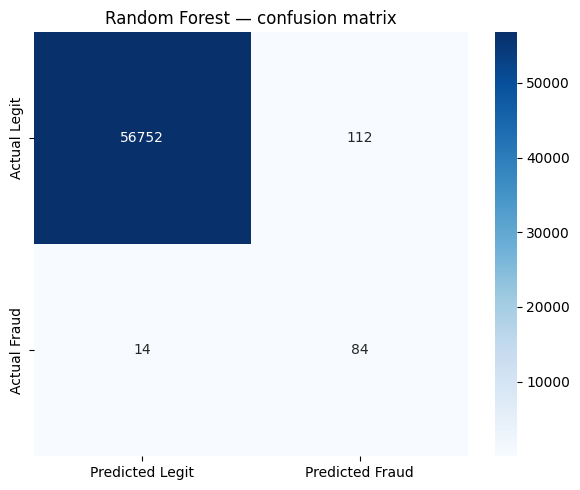

In [6]:
import seaborn as sns
cm = confusion_matrix(y_test, rf_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Legit", "Predicted Fraud"],
            yticklabels=["Actual Legit", "Actual Fraud"], ax=ax)
ax.set_title("Random Forest — confusion matrix")
plt.tight_layout()
plt.savefig("../reports/rf_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_test_t  = torch.FloatTensor(y_test).to(device)

# DataLoader batches the data so we train on small chunks at a time
# rather than loading all 454,902 rows into the GPU at once
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=2048, shuffle=True)

print(f"Tensors moved to: {X_train_t.device}")
print(f"Training batches per epoch: {len(train_loader)}")

Tensors moved to: cuda:0
Training batches per epoch: 223


In [8]:
class FraudDetectionNet(nn.Module):
    """
    A feedforward neural network for binary fraud classification.
    
    Architecture:
        Input (29 features)
            → Hidden layer 1 (128 neurons) + BatchNorm + ReLU + Dropout
            → Hidden layer 2 (64 neurons)  + BatchNorm + ReLU + Dropout
            → Hidden layer 3 (32 neurons)  + BatchNorm + ReLU
            → Output (1 neuron, sigmoid → probability 0–1)
    """
    def __init__(self, input_size):
        super(FraudDetectionNet, self).__init__()
        
        self.network = nn.Sequential(
            # Layer 1
            nn.Linear(input_size, 128),  # 29 inputs → 128 neurons
            nn.BatchNorm1d(128),          # normalises activations within batch
            nn.ReLU(),                    # activation function: max(0, x)
            nn.Dropout(0.3),              # randomly zeros 30% of neurons during training
            
            # Layer 2
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            # Layer 3
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            
            # Output layer — single neuron, sigmoid squashes to 0–1 probability
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x).squeeze(1)


# Instantiate and move the model to GPU
model = FraudDetectionNet(input_size=X_train.shape[1]).to(device)
print(model)
print(f"\nTotal trainable parameters: {sum(p.numel() for p in model.parameters()):,}")

FraudDetectionNet(
  (network): Sequential(
    (0): Linear(in_features=29, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Linear(in_features=32, out_features=1, bias=True)
    (12): Sigmoid()
  )
)

Total trainable parameters: 14,657


In [9]:
# Loss function: measures how wrong the model is on each batch
# BCELoss = Binary Cross-Entropy — standard for binary classification (fraud/not fraud)
criterion = nn.BCELoss()

# Optimiser: adjusts model weights to reduce the loss
# Adam is the most popular optimiser — adaptive and fast
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Track metrics across epochs
history = {"train_loss": [], "train_acc": []}

EPOCHS = 20
print(f"Training on {device} for {EPOCHS} epochs...\n")
start = time.time()

for epoch in range(EPOCHS):
    model.train()  # set to training mode (enables Dropout)
    
    epoch_loss = 0
    correct    = 0
    total      = 0
    
    for X_batch, y_batch in train_loader:
        # 1. Forward pass: run inputs through the network
        predictions = model(X_batch)
        
        # 2. Calculate loss: how wrong were we?
        loss = criterion(predictions, y_batch)
        
        # 3. Zero gradients (PyTorch accumulates them by default)
        optimizer.zero_grad()
        
        # 4. Backward pass: compute gradients via backpropagation
        loss.backward()
        
        # 5. Update weights in the direction that reduces loss
        optimizer.step()
        
        # Track metrics
        epoch_loss += loss.item()
        predicted   = (predictions >= 0.5).float()
        correct    += (predicted == y_batch).sum().item()
        total      += y_batch.size(0)
    
    avg_loss = epoch_loss / len(train_loader)
    accuracy = correct / total * 100
    history["train_loss"].append(avg_loss)
    history["train_acc"].append(accuracy)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d}/{EPOCHS}  |  Loss: {avg_loss:.4f}  |  Accuracy: {accuracy:.2f}%")

elapsed = time.time() - start
print(f"\nTraining complete in {elapsed:.1f} seconds on {torch.cuda.get_device_name(0)}")

Training on cuda for 20 epochs...

Epoch 05/20  |  Loss: 0.0158  |  Accuracy: 99.54%
Epoch 10/20  |  Loss: 0.0082  |  Accuracy: 99.78%
Epoch 15/20  |  Loss: 0.0059  |  Accuracy: 99.84%
Epoch 20/20  |  Loss: 0.0045  |  Accuracy: 99.89%

Training complete in 52.0 seconds on NVIDIA GeForce RTX 5080


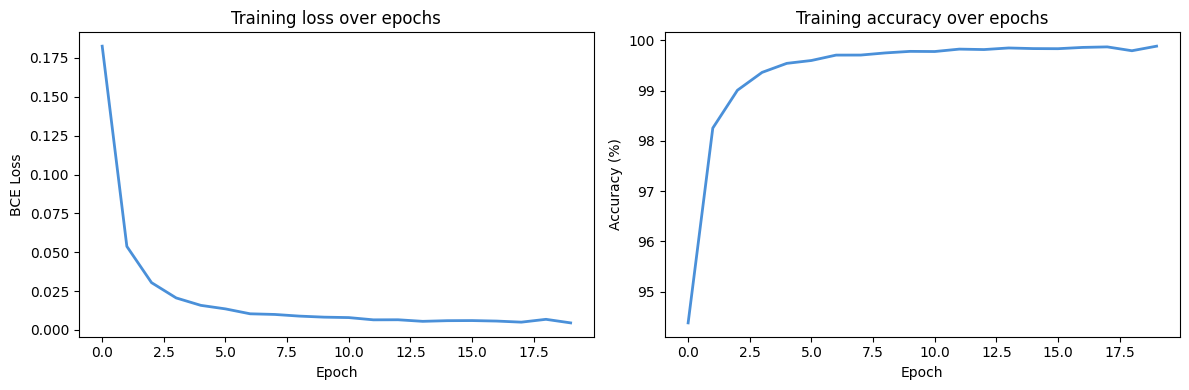

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], color="#4A90D9", linewidth=2)
axes[0].set_title("Training loss over epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")

axes[1].plot(history["train_acc"], color="#4A90D9", linewidth=2)
axes[1].set_title("Training accuracy over epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")

plt.tight_layout()
plt.savefig("../reports/nn_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
model.eval()  # set to evaluation mode (disables Dropout)

with torch.no_grad():  # no need to track gradients during evaluation
    nn_probs = model(X_test_t).cpu().numpy()
    nn_preds = (nn_probs >= 0.5).astype(int)

print("=" * 50)
print("NEURAL NETWORK — TEST SET RESULTS")
print("=" * 50)
print(classification_report(y_test, nn_preds,
                             target_names=["Legitimate", "Fraud"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test, nn_probs):.4f}")

NEURAL NETWORK — TEST SET RESULTS
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.61      0.87      0.72        98

    accuracy                           1.00     56962
   macro avg       0.81      0.93      0.86     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9664


C:\Users\kausy\anaconda3\envs\fraud-detection\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\kausy\anaconda3\envs\fraud-detection\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


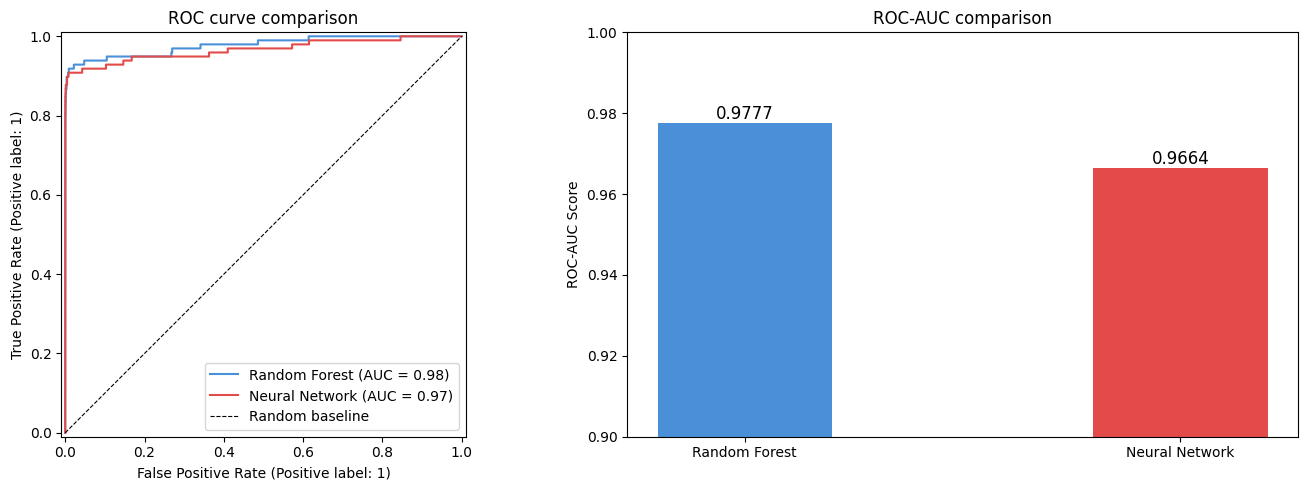

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves for both models
RocCurveDisplay.from_predictions(y_test, rf_probs,
    name="Random Forest", ax=axes[0], color="#4A90D9")
RocCurveDisplay.from_predictions(y_test, nn_probs,
    name="Neural Network", ax=axes[0], color="#E24B4A")
axes[0].set_title("ROC curve comparison")
axes[0].plot([0,1],[0,1],"k--", linewidth=0.8, label="Random baseline")
axes[0].legend()

# ROC-AUC bar comparison
scores = {"Random Forest": roc_auc_score(y_test, rf_probs),
          "Neural Network": roc_auc_score(y_test, nn_probs)}
axes[1].bar(scores.keys(), scores.values(),
            color=["#4A90D9", "#E24B4A"], width=0.4)
axes[1].set_ylim(0.9, 1.0)
axes[1].set_title("ROC-AUC comparison")
axes[1].set_ylabel("ROC-AUC Score")
for i, (k, v) in enumerate(scores.items()):
    axes[1].text(i, v + 0.001, f"{v:.4f}", ha="center", fontsize=12)

plt.tight_layout()
plt.savefig("../reports/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
import os, joblib
os.makedirs("../models", exist_ok=True)

# Save Random Forest (Scikit-learn uses joblib)
joblib.dump(rf_model, "../models/random_forest.joblib")

# Save Neural Network (PyTorch saves state_dict — the learned weights)
torch.save(model.state_dict(), "../models/fraud_net.pt")

print("Models saved to models/")

Models saved to models/
